# Алгоритмы обучения с подкреплением

**Цель работы:** исследование базовых алгоритмов обучения с подкреплением (Reinforcement Learning) на примере классической задачи балансировки шеста CartPole и другой среды из набора gym.

**Постановка задачи:** Осуществить практическое знакомство с алгоритмами обучения с подкреплением, описанными в книге Лю Ю. (Х.) "Обучение с подкреплением на PyTorch". Исследовать влияние размера батча (1, 10, 100) в алгоритме градиента стратегии. Для среды FrozenLake-v1 реализовать алгоритм SARSA.

## Описание задачи и постановки эксперимента

### Описание среды CartPole

CartPole (Тележка и Шест) — это классическая задача в области обучения с подкреплением, где агенту нужно научиться удерживать вертикально установленный на подвижной тележке шест, перемещая тележку влево или вправо, чтобы предотвратить его падение, что является неустойчивым равновесием

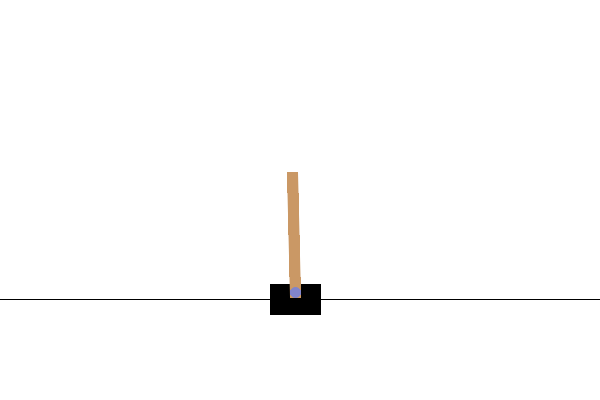

In [2]:
import gymnasium as gym
import torch

env = gym.make("CartPole-v0", render_mode="rgb_array")

c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\gymnasium\envs\registration.py:512: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


#### Состояния

Наблюдение в среде CartPole представлено массивом формы (4,), где каждый элемент соответствует одному из параметров системы:

1. **Положение тележки**
2. **Скорость тележки**
3. **Угол наклона шеста**
4. **Угловая скорость шеста**

Каждый параметр имеет свой формальный диапазон значений, однако важно различать:

- диапазон пространства наблюдений Gym,  
- и реальные ограничения среды, при выходе за которые эпизод завершается.

Особенности:

- Положение тележки формально может находиться в диапазоне (`-4.8`, `4.8`),  
  но эпизод завершается, если тележка выходит за пределы (`-2.4`, `2.4`).

- Угол наклона шеста может принимать значения (`-0.418`, `0.418`) радиан (≈ `±24°`),  
  но эпизод завершается, если угол превышает (`-0.2095`, `0.2095`) радиан (≈ `±12°`).

Таким образом, пространство наблюдений модели шире, чем фактическое пространство допустимых состояний, при которых эпизод продолжается. Это позволяет Gym обеспечивать единый интерфейс наблюдений, независимо от условий завершения эпизода.


In [3]:
env.observation_space

Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)

#### Пространство действий

Действие представляет собой массив данных с формой (1,), который может принимать значения {0, 1}, указывающие направление фиксированного усилия, с которым тележка толкается.

0: Толкать тележку влево

1: Толкать тележку вправо

Примечание: Скорость, которая уменьшается или увеличивается в зависимости от приложенной силы, не является фиксированной и зависит от угла наклона шеста. Центр тяжести шеста влияет на количество энергии, необходимое для перемещения тележки под ним

In [4]:
env.action_space

Discrete(2)

### Вознаграждения (Rewards)

Цель агента в среде CartPole — удерживать шест в вертикальном положении как можно дольше. Поэтому по умолчанию используется простая система вознаграждений:

- `+1` за каждый выполненный шаг, включая шаг, на котором происходит завершение эпизода.

Из-за ограничений по времени стандартные пороги успешности разные:

- Для CartPole-v1: порог вознаграждения = `500`
- Для CartPole-v0: порог вознаграждения = `200`



#### Условие завершения эпизода

Эпизод в среде CartPole заканчивается, если выполняется любое из следующих условий:

1. Termination (завершение по состоянию среды)

    - Угол наклона шеста превышает допустимый диапазон ±12° (примерно ±0.2095 рад)

    - Позиция тележки выходит за границы ±2.4, что соответствует достижению краёв видимой области

2. Truncation (завершение по лимиту времени)
    Длина эпизода превышает:
    - 500 шагов для CartPole-v1
    - 200 шагов для CartPole-v0

Truncation не относится к ошибке поведения агента — эпизод просто принудительно обрывается при достижении максимального времени.


### Алгоритм гридиент стратегии

Алгоритм градиента стратегии относится к классу методов прямой оптимизации стратегии. В отличие от детерминированных подходов, таких как случайный поиск или восхождение на вершину, данный метод оптимизирует не отдельные действия, а распределение вероятностей действий, задаваемое параметризованной моделью.

В процессе работы модель (стратегия) получает состояние среды и вычисляет вероятности всех возможных действий с помощью функции Softmax. Затем действие выбирается случайно, пропорционально этим вероятностям, что делает стратегию стохастической. Это позволяет алгоритму лучше исследовать пространство действий и избегать преждевременной фиксации на одном варианте поведения.

В течение эпизода алгоритм собирает траекторию: состояния, выбранные действия, вероятности и полученные награды. После завершения эпизода происходит обновление весов стратегии. Параметры изменяются в направлении градиента ожидаемого вознаграждения, усиливая вероятность тех действий, которые привели к хорошим результатам. Таким образом стратегия постепенно обучается генерировать более полезные действия.

Определим функцию run_episode, которая получает на входе веса, имитирует эпизод и возвращает полное вознаграждение и градиенты. Точнее,
на каждом шаге она выполняет следующие действия:
* вычисляет вероятности probs обоих действий, зная текущее состояние и входные веса;
* выбирает действие action в соответствии с вычисленными вероятностями;
* вычисляет производные d_softmax функции softmax, которой передаются вероятности;
* делит вычисленные производные d_softmax на вероятности и получает производные d_log логарифма стратегии;
* применяет правило дифференцирования сложной функции, чтобы
* вычислить градиент grad по весам;
* запоминает результирующий градиент grad;
* выполняет действие, увеличивает полное вознаграждение и обновляет состояние

In [5]:
n_state = env.observation_space.shape[0]

n_action = env.action_space.n

n_episode = 500
weight = torch.rand(n_state, n_action)
total_rewards = []
learning_rate = 0.001

In [6]:
def run_episode(env, weight):
    state, info = env.reset()
    grads = []
    total_reward = 0
    is_done = False
    while not is_done:
        state = torch.from_numpy(state).float()
        z = torch.matmul(state, weight)
        probs = torch.nn.Softmax()(z)
        action = int(torch.bernoulli(probs[1]).item())

        d_softmax = torch.diag(probs) - probs.view(-1, 1) * probs
        d_log = d_softmax[action] / probs[action]

        grad = state.view(-1, 1) * d_log

        grads.append(grad)

        state, reward, terminated, truncated, info = env.step(action)

        is_done = terminated or truncated

        total_reward += reward
        if is_done:
            break
    return total_reward, grads



#### Обучение 

In [7]:
import imageio
import os
video_dir = './cartpole_video/'
frames = []
# env = gym.wrappers.RecordVideo(env, video_dir, episode_trigger=lambda e: e % 100 == 0)

for episode in range(n_episode):
    total_reward, gradients = run_episode(env, weight)
    frames.append(env.render())
    print('Эпизод {}: {}'.format(episode + 1, total_reward))
    for i, gradient in enumerate(gradients):
        weight += learning_rate * gradient * (total_reward - i)
    total_rewards.append(total_reward)
# gif_path = os.path.join(video_dir, "cartpole.gif")
# imageio.mimsave(gif_path, frames, fps=10)
# print(f"GIF сохранен: {gif_path}")

c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Эпизод 1: 36.0
Эпизод 2: 21.0
Эпизод 3: 24.0
Эпизод 4: 27.0
Эпизод 5: 45.0
Эпизод 6: 15.0
Эпизод 7: 25.0
Эпизод 8: 12.0
Эпизод 9: 12.0
Эпизод 10: 52.0
Эпизод 11: 18.0
Эпизод 12: 27.0
Эпизод 13: 24.0
Эпизод 14: 28.0
Эпизод 15: 26.0
Эпизод 16: 23.0
Эпизод 17: 20.0
Эпизод 18: 50.0
Эпизод 19: 20.0
Эпизод 20: 19.0
Эпизод 21: 35.0
Эпизод 22: 29.0
Эпизод 23: 48.0
Эпизод 24: 19.0
Эпизод 25: 49.0
Эпизод 26: 34.0
Эпизод 27: 12.0
Эпизод 28: 81.0
Эпизод 29: 20.0
Эпизод 30: 16.0
Эпизод 31: 75.0
Эпизод 32: 60.0
Эпизод 33: 46.0
Эпизод 34: 64.0
Эпизод 35: 59.0
Эпизод 36: 55.0
Эпизод 37: 21.0
Эпизод 38: 86.0
Эпизод 39: 129.0
Эпизод 40: 71.0
Эпизод 41: 68.0
Эпизод 42: 34.0
Эпизод 43: 28.0
Эпизод 44: 105.0
Эпизод 45: 42.0
Эпизод 46: 43.0
Эпизод 47: 51.0
Эпизод 48: 65.0
Эпизод 49: 64.0


c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Эпизод 50: 44.0
Эпизод 51: 25.0
Эпизод 52: 78.0
Эпизод 53: 43.0
Эпизод 54: 97.0
Эпизод 55: 34.0
Эпизод 56: 113.0
Эпизод 57: 95.0
Эпизод 58: 54.0
Эпизод 59: 185.0
Эпизод 60: 164.0
Эпизод 61: 153.0
Эпизод 62: 200.0
Эпизод 63: 151.0
Эпизод 64: 183.0
Эпизод 65: 67.0
Эпизод 66: 63.0
Эпизод 67: 132.0
Эпизод 68: 172.0
Эпизод 69: 118.0
Эпизод 70: 122.0
Эпизод 71: 144.0
Эпизод 72: 200.0
Эпизод 73: 73.0
Эпизод 74: 107.0
Эпизод 75: 200.0
Эпизод 76: 200.0
Эпизод 77: 200.0
Эпизод 78: 200.0
Эпизод 79: 190.0
Эпизод 80: 158.0
Эпизод 81: 147.0
Эпизод 82: 128.0
Эпизод 83: 189.0
Эпизод 84: 200.0
Эпизод 85: 200.0
Эпизод 86: 80.0
Эпизод 87: 200.0
Эпизод 88: 194.0
Эпизод 89: 86.0
Эпизод 90: 183.0
Эпизод 91: 123.0
Эпизод 92: 117.0
Эпизод 93: 60.0
Эпизод 94: 146.0
Эпизод 95: 200.0
Эпизод 96: 200.0
Эпизод 97: 200.0
Эпизод 98: 200.0
Эпизод 99: 200.0
Эпизод 100: 200.0
Эпизод 101: 200.0
Эпизод 102: 200.0
Эпизод 103: 200.0
Эпизод 104: 200.0
Эпизод 105: 200.0
Эпизод 106: 200.0
Эпизод 107: 157.0
Эпизод 108: 99.0
Эпи

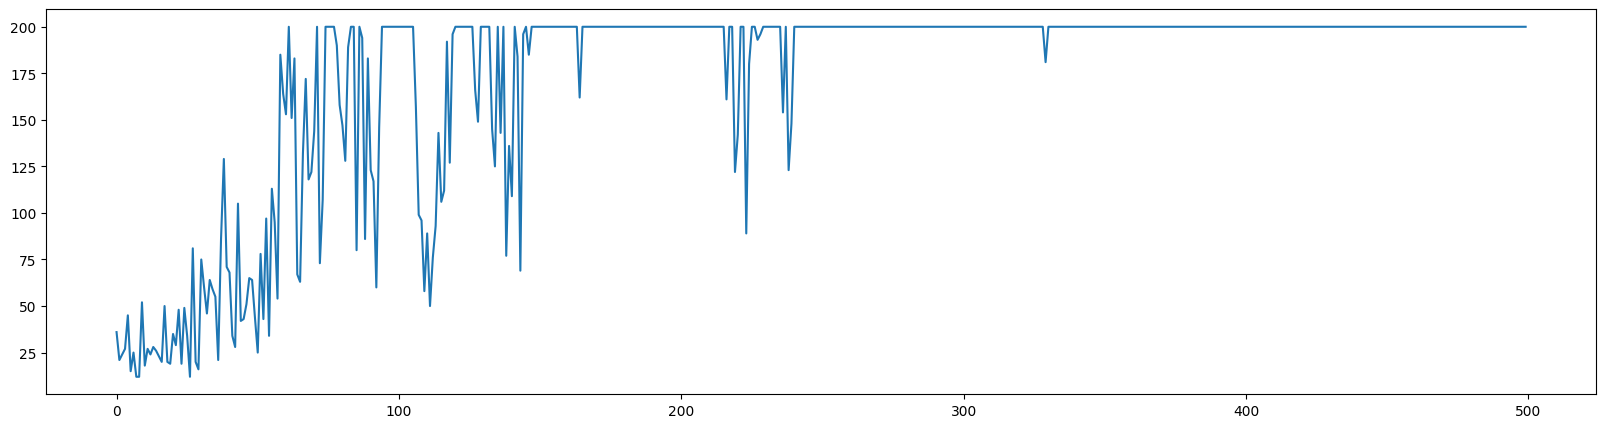

In [8]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(20,5))
plt.plot(total_rewards)

Посмотрев на график зависимости вознаграждения от количества эпизодов, можно прийти к выводу, что обучение можно остановить раньше, как только задача будет решена, т. е. среднее полное вознаграждение в 100 последовательных эпизодах окажется не меньше 195.

Исследуем влияние батча

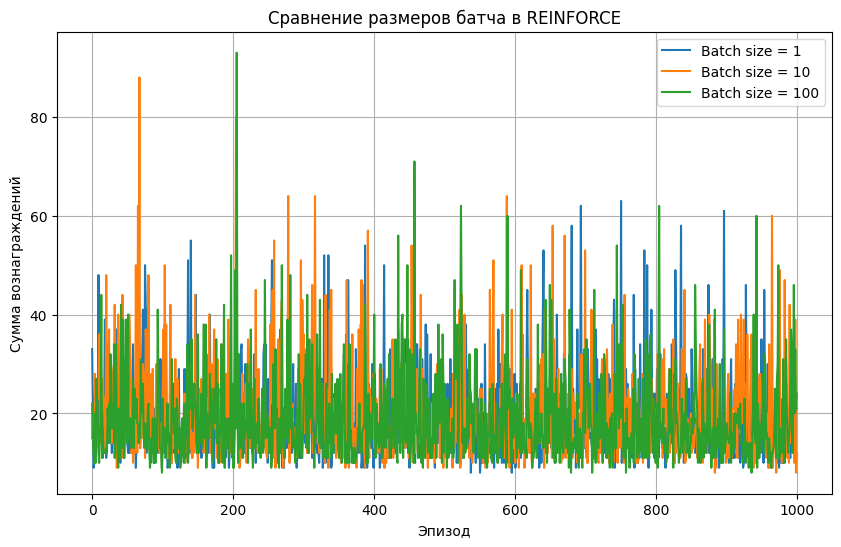

In [9]:
import torch
import gymnasium as gym
import matplotlib.pyplot as plt

# Настройки среды и обучения
env_name = "CartPole-v1"
n_episode = 1000  # для ускорения эксперимента
learning_rate = 0.01
gamma = 0.99
batch_sizes = [1, 10, 100]

def run_episode(env, weight):
    state, _ = env.reset()
    grads = []
    rewards = []
    done = False
    while not done:
        state_tensor = torch.from_numpy(state).float()
        z = state_tensor @ weight
        probs = torch.nn.Softmax(dim=0)(z)
        m = torch.distributions.Categorical(probs)
        action = m.sample()
        grads.append(state_tensor.view(-1,1))
        state, reward, terminated, truncated, _ = env.step(action.item())
        done = terminated or truncated
        rewards.append(reward)
    return rewards, grads

def discounted_rewards(rewards, gamma):
    G = 0
    returns = []
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    return returns

all_rewards = {}
for batch_size in batch_sizes:
    env = gym.make(env_name)
    n_state = env.observation_space.shape[0]
    n_action = env.action_space.n
    weight = torch.rand(n_state, n_action)
    total_rewards = []
    batch_grads = []

    for episode in range(n_episode):
        rewards, grads = run_episode(env, weight)
        returns = discounted_rewards(rewards, gamma)
        for g, R in zip(grads, returns):
            batch_grads.append(g * R)
        
        if (episode + 1) % batch_size == 0:
            avg_grad = torch.stack(batch_grads).mean(dim=0)
            with torch.no_grad():
                weight += learning_rate * avg_grad
            batch_grads = []

        total_rewards.append(sum(rewards))
    
    all_rewards[batch_size] = total_rewards
    env.close()

plt.figure(figsize=(10,6))
for batch_size, rewards in all_rewards.items():
    plt.plot(rewards, label=f'Batch size = {batch_size}')
plt.xlabel('Эпизод')
plt.ylabel('Сумма вознаграждений')
plt.title('Сравнение размеров батча в REINFORCE')
plt.legend()
plt.grid(True)
plt.show()


### Описание среды  FrozenLake-v1

FrozenLake-v1 — это дискретная среда из набора Gymnasium, в которой агенту нужно добраться от стартовой клетки до целевой, двигаясь по замёрзшему озеру, стараясь не провалиться в пропасть.

Она моделирует задачу поиска пути в стохастической среде, где поверхность может быть скользкой.

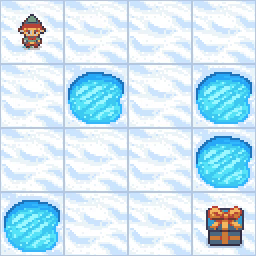

In [52]:
env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")

#### Состояния

В среде FrozenLake-v1 состояние представлено одним целым числом, определяющим текущую позицию агента на карте. Поле имеет форму сетки размера nrows × ncols, где каждая клетка пронумерована последовательно — слева направо и сверху вниз. Индекс состояния вычисляется по формуле: state = current_row * ncols + current_col, где строки и столбцы нумеруются с нуля. Например, цель в стандартной карте 4×4 расположена в клетке (3, 3), и её индекс равен 3 * 4 + 3 = 15. Таким образом, число возможных состояний равно nrows * ncols (для 4×4 — 16 состояний).

In [11]:
env.observation_space

Discrete(16)

#### Пространство действий

В среде FrozenLake-v1 пространство действий дискретное и представлено одним целым числом в диапазоне от 0 до 3. Каждое действие задаёт направление движения агента на одну клетку: 0 — влево, 1 — вниз, 2 — вправо, 3 — вверх. Таким образом, в каждый момент времени агент выбирает одно из четырёх возможных направлений перемещения.

In [12]:
env.action_space

Discrete(4)

### Вознаграждения (Rewards)

В среде FrozenLake-v1 используется разреженная схема вознаграждений: агент получает +1 только при достижении клетки цели (Goal), тогда как переход на замёрзшую клетку (Frozen) или попадание в яму (Hole) приносит вознаграждение 0. Таким образом, единственным положительным стимулом является успешное завершение эпизода, что делает задачу обучения сложной и мотивирует агента искать путь, приводящий к цели.


#### Условие завершения эпизода

Эпизод в среде FrozenLake-v1 завершается в двух случаях. Termination происходит, если агент попадает в яму (Hole) или достигает цели (Goal) в правом нижнем углу карты (индекс max(nrow) * max(ncol) - 1). Truncation

### Алгоритм SARSA

**SARSA (State–Action–Reward–State–Action)** — метод онлайн Q-обучения, который обновляет значения Q-функции с учётом действий, фактически выбранных агентом.

### Формула обновления

$
Q(s_t, a_t) \gets Q(s_t, a_t) + \alpha \left[ r_{t+1} + \gamma Q(s_{t+1}, a_{t+1}) - Q(s_t, a_t) \right]
$

Где:

- $s_t$ — текущее состояние  
- $a_t$ — выбранное действие в $s_t$  
- $r_{t+1}$ — вознаграждение после действия  
- $s_{t+1}$ — новое состояние  
- $a_{t+1}$ — действие, выбранное в новом состоянии  
- $\alpha$ — коэффициент обучения (learning rate)  
- $\gamma$ — коэффициент дисконтирования

In [88]:


n_state = env.observation_space.n

n_action = env.action_space.n

qtable = torch.zeros(env.observation_space.n, env.action_space.n, dtype=torch.float64)

n_episode = 1000



In [89]:
success = []
video_dir = './frozenlake_video/'

alpha = 0.1     
gamma = 0.1    
qtables = []    

# env = gym.wrappers.RecordVideo(env, video_dir, episode_trigger=lambda e: e % 200 == 0)
for _ in range(n_episode):
    state = env.reset()[0]
    terminated = False
    success.append(0)

    while not terminated:
        if torch.max(qtable[state]) > 0:
            action = int(torch.argmax(qtable[state]))
        else:
            action = env.action_space.sample()
        
        new_state, reward, terminated, *_ = env.step(action)

        qtable[state, action] = qtable[state, action] + alpha * (reward + gamma * torch.max(qtable[new_state]) - qtable[state, action])
        state = new_state

        if reward:
            success[-1] = 1

    qtables.append(qtable.clone().detach())


In [86]:
qtables

[tensor([[0.0000e+00, 0.0000e+00, 5.9049e-01, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 6.5610e-01, 0.0000e+00],
         [0.0000e+00, 7.2900e-01, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 8.1000e-01, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 7.2900e-05, 0.0000e+00],
         [0.0000e+00, 2.9970e-03, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 9.0000e-01, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 5.9536e-02, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00]], dtype=torch.float64),
 tensor([[0.0000e+00, 0.0000e+00,

In [92]:
import imageio.v2 as imageio
import os

video_dir = './frozenlake_video/'
mp4_path = os.path.join(video_dir, "rl-video-episode-10800.mp4")   # или твой файл
gif_path = os.path.join(video_dir, "frozenlake1.gif")

# читаем все кадры из mp4
frames = []
reader = imageio.get_reader(mp4_path)

for frame in reader:
    frames.append(frame)

reader.close()

# сохраняем GIF
imageio.mimsave(gif_path, frames, fps=10)

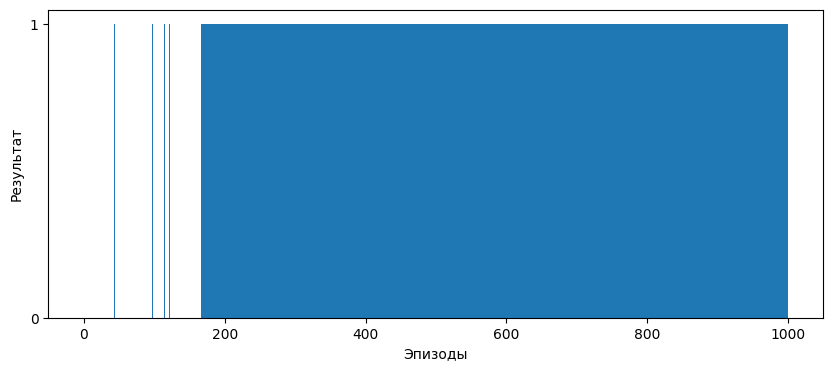

In [90]:
plt.figure(figsize=(10, 4))
plt.bar(range(len(success)), success, width=1.0)
plt.xlabel('Эпизоды')
plt.yticks([0,1])
plt.ylabel('Результат')
plt.show()

### Результаты обучения

#### CartPole
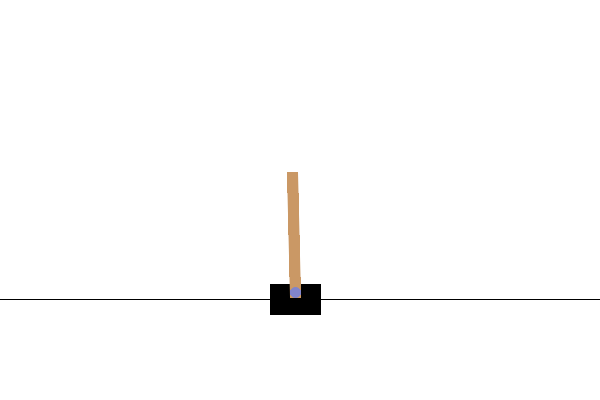

#### FrozenLake

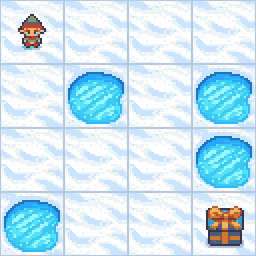
